In [24]:
import numpy as np
import rawpy


def convolution(image, kernel):
    H, W = image.shape
    h, w = kernel.shape
    pad_h = h // 2
    pad_w = w // 2

    padded = np.zeros((H + (2 * pad_h), W + (2 * pad_w)))
    padded[pad_h : pad_h + H, pad_w : pad_w + W] = image

    kernel_flipped = np.flip(kernel, axis=0)
    kernel_flipped = np.flip(kernel_flipped, axis=1)

    final = np.zeros((H, W))

    for x in range(H):
        for y in range(W):
            kern_val = 0
            for u in range(h):
                for v in range(w):
                    kern_val += padded[x + u, y + v] * kernel_flipped[u, v]
            final[x, y] = kern_val

    return final




In [ ]:
def fft_convolution(image, kernel):
    H, W = image.shape
    h, w = kernel.shape
    pad_h = h // 2
    pad_w = w // 2
    pad_H = H // 2
    pad_W = W // 2

    padded = np.zeros((H, W))
    padded[pad_H - pad_h : pad_h + pad_H + 1, pad_W - pad_w : pad_w + pad_W + 1] = kernel
    padded = np.fft.ifftshift(padded)
    fft_i = np.fft.fft2(image)
    fft_k = np.fft.fft2(padded)

    fft_conv =  fft_i * fft_k
    conv = np.fft.ifft2(fft_conv)
    return np.real(conv)

In [26]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [27]:
import scipy
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("hughes.jpg", cv2.IMREAD_GRAYSCALE)
kernel = np.ones((9, 9), np.float32)
kernel = kernel / 81
fft_conv = fft_convolution(img, kernel)
conv = scipy.ndimage.convolve(img, kernel)


114728.2805125834


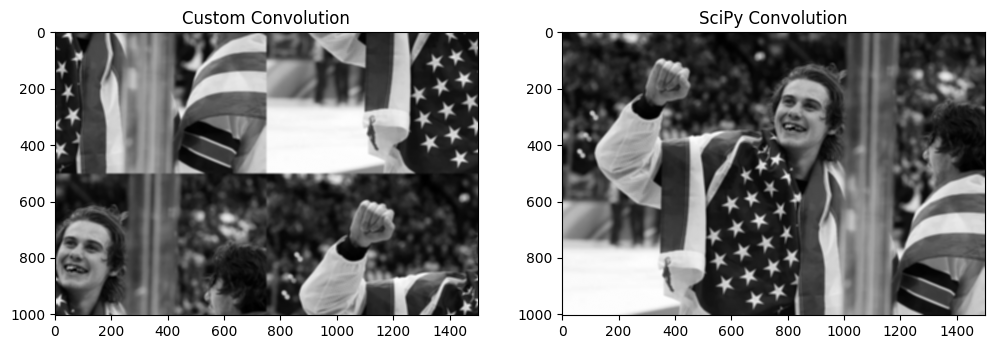

In [33]:
similarity = np.linalg.norm(fft_conv - conv, 'fro')
print(similarity)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Custom Convolution")
plt.imshow(fft_conv.real , cmap='gray')
plt.subplot(1, 2, 2)
plt.title("SciPy Convolution")
plt.imshow(conv, cmap='gray')
plt.show()